# Embedding ArXiv Papers

This notebook demonstrates an example use of the information weight for embedding count data.
The dataset is a collection of computer science papers posted to arXiv between 2014 and 2017, and we have crossed referenced with [OpenAlex](https://openalex.org/) [1] to obtain a list of ids that the paper references.
Each paper is transformed into a high-dimensional vector that is a combination of counts of word counts in the abstract and a one-hot encoding of the reference ids.
Each paper also comes with a user-chosen primary-category that we treat as ground truth class labels.

In [17]:
import warnings

# Suppress warnings
warnings.simplefilter("ignore")

In [ ]:
import datamapplot
import glasbey
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import umap
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics import silhouette_score

from infoweight import InformationWeightTransformer

# Ensure we don't generate large images for inline docs
# You probably want to remove this if running the notebook yourself
plt.rcParams["figure.dpi"] = 72

## Load the data

The data is provided in the file `arxiv_cs.feather` that is found in the `data` folder.
Let's load the data into a pandas dataframe and apply scikit-learn's `CountVectorizer` to the title, abstract, and references columns.

In [18]:
df = pd.read_feather("data/arxiv_cs.feather")
df["references"] = df["references"].apply(
    " ".join
)  # Change reference from a list to a string for the CountVectorizer
df

,id,category,created,title,references,abstract
14,1212.0692,cs.AI,2014-01-05,An Empirical Evaluation of Portfolios Approach...,32539537 109784087 113569212 1500443963 155310...,Recent research in in in areas such as as SAT ...
15,1302.4381,cs.AI,2014-01-06,Reasoning about Independence in Probabilistic ...,73939759 148995703 156498718 158290890 8248903...,We We We We extend the the the the theory theo...
16,1312.4232,cs.AI,2014-01-04,Geometric lattice structure of covering and it...,74588876 1506662207 1729273939 1851672339 1964...,The reduction reduction reduction reduction of...
18,1401.0802,cs.AI,2014-01-04,A stochastic model for Case-Based Reasoning,24106767 107723980 1975564911 2070429602 20753...,Case-Bsed Reasoning (CBR) is is a a a a a rece...
19,1401.1024,cs.AI,2014-01-06,Solver Scheduling via Answer Set Programming,32539537 42823784 43305077 60686164 71637970 1...,Although Boolean Constraint Technology has mad...
...,...,...,...,...,...,...
259319,1610.05838,cs.LG,2016-11-10,CuMF_SGD: Fast and Scalable Matrix Factorization,18599363 24714140 1542014621 1630668835 183391...,Matrix factorization (MF) has been widely used...
259324,1610.07722,cs.LG,2016-10-25,Sparse Hierarchical Tucker Factorization and i...,111803032 1636040588 1825959699 1963826206 196...,We We propose a a a a a a a a a a a new tensor...
259326,1611.01142,cs.LG,2016-11-03,Using a Deep Reinforcement Learning Agent for ...,33871791 1595483645 1869778509 1969758122 2020...,Ensuring transportation transportation systems...
259329,1611.05095,cs.LG,2016-11-15,Learning Dexterous Manipulation Policies from ...,195033972 1499669280 1520597402 1564755532 196...,We We We We explore learning-based approaches ...


In [19]:
count_vectorizer = CountVectorizer(
    min_df=3
)  # Only keep words or references that appear in at least 3 papers
# This limit is arbitrary but significantly cuts down the number of dimensions.
title_counts = count_vectorizer.fit_transform(df["title"])
word_counts = count_vectorizer.fit_transform(df["abstract"])
ref_counts = count_vectorizer.fit_transform(df["references"])
joint_counts = sp.hstack([title_counts, word_counts, ref_counts])
joint_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1072500 stored elements and shape (9817, 29710)>

## Some Exploratory Analysis

Lets do some preliminary EDA of the data.

Text(0.5, 1.0, 'Distribution of Categories')

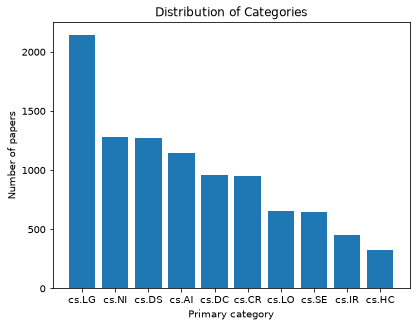

In [20]:
category_counts = df["category"].value_counts()
plt.bar(category_counts.index.values, category_counts.values)
plt.xlabel("Primary category")
plt.ylabel("Number of papers")
plt.title("Distribution of Categories")

Text(0.5, 1.0, 'Distribution of the Title Length')

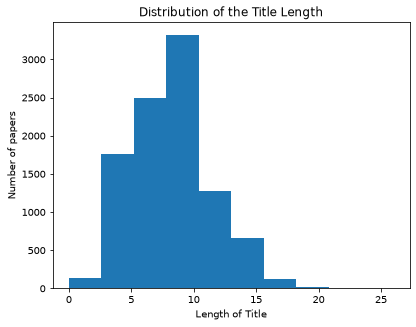

In [21]:
plt.hist(title_counts.sum(axis=1))
plt.xlabel("Length of Title")
plt.ylabel("Number of papers")
plt.title("Distribution of the Title Length")

Text(0.5, 1.0, 'Distribution of the Lengths of Abstracts')

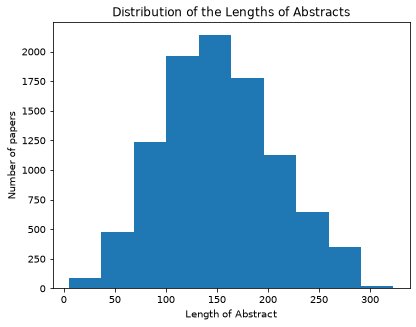

In [22]:
plt.hist(word_counts.sum(axis=1))
plt.xlabel("Length of Abstract")
plt.ylabel("Number of papers")
plt.title("Distribution of the Lengths of Abstracts")

Text(0.5, 1.0, 'Distribution of the Number of References')

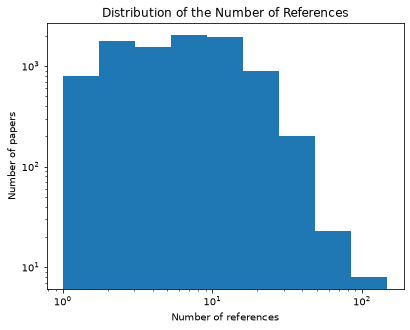

In [23]:
n_references = (
    np.asarray(ref_counts.sum(axis=1)).reshape(-1) + 1
)  # Some have zeros but that makes the plot strange
bins = np.geomspace(np.min(n_references), np.max(n_references), 10)
plt.hist(ref_counts.sum(axis=1), bins=bins)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of references")
plt.ylabel("Number of papers")
plt.title("Distribution of the Number of References")

We can see that the distribution of categories is not equal, but not terribly far from equal.
The largest category (machine learning) is about 4.5x the smallest category (human computer interaction).

The length of the abstracts vary quite a bit, but look to follow a nice normal distribution with a mean around 150 words.

The distribution of the number of reference looks like a powerlaw, that is number of references $R$ has probability $P(R = r) \propto r^{-
\alpha}$ for some $\alpha > 0$.
Notice that the plot is log-log scaled, and the bin heights seem to decrease linearly above $\approx 10$ references.
Most papers have only a few while a handful have hundreds.
One of the benefits of using the information weight over tf-idf is that the information weight accounts for differences in document length (or in this case, number of references), so we can hope to see some improvement here.

## Apply Transforms

Let's apply `TF-IDF`, the `Information Weight`, and Aizawa's [2] probability weighted information transforms to the count data.
We'll apply the transforms to each count matrix separately and the concatenate them to give each paper a single high dimensional vector.
We could instead concatenate the matrices first and then the InformationWeightTransforms's `column_groups` parameter to separate the variable types.

In [24]:
%%time
tfidf = TfidfTransformer(norm=None, smooth_idf=False)
tfidf_title_counts = tfidf.fit_transform(title_counts)
tfidf_word_counts = tfidf.fit_transform(word_counts)
tfidf_ref_counts = tfidf.fit_transform(ref_counts)
tfidf_joint_counts = sp.hstack(
    [tfidf_title_counts, tfidf_word_counts, tfidf_ref_counts]
)
tfidf_joint_counts

CPU times: user 39.4 ms, sys: 8.36 ms, total: 47.7 ms
Wall time: 54.4 ms


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1072500 stored elements and shape (9817, 29710)>

In [9]:
%%time
iwt = InformationWeightTransformer()
iwt_title_counts = iwt.fit_transform(title_counts)
iwt_word_counts = iwt.fit_transform(word_counts)
iwt_ref_counts = iwt.fit_transform(ref_counts)
iwt_joint_counts = sp.hstack([iwt_title_counts, iwt_word_counts, iwt_ref_counts])
iwt_joint_counts

CPU times: user 1.18 s, sys: 25.5 ms, total: 1.21 s
Wall time: 1.23 s


<COOrdinate sparse matrix of dtype 'float64'
	with 1072500 stored elements and shape (9817, 29710)>

That feels a bit slow.
The `InformationWeightTransformer` is as fast (or slightly faster) than `TfidfTransformer`, but on it's first run requires compling some internal functions using `numba`.
If we run it again, we will see a more accurate measure of it's runtime.

In [10]:
%%time
iwt = InformationWeightTransformer()
iwt_title_counts = iwt.fit_transform(title_counts)
iwt_word_counts = iwt.fit_transform(word_counts)
iwt_ref_counts = iwt.fit_transform(ref_counts)
iwt_joint_counts = sp.hstack([iwt_title_counts, iwt_word_counts, iwt_ref_counts])
iwt_joint_counts

CPU times: user 18.7 ms, sys: 6.48 ms, total: 25.2 ms
Wall time: 21 ms


<COOrdinate sparse matrix of dtype 'float64'
	with 1072500 stored elements and shape (9817, 29710)>

In [11]:
def pwi(data):  # Probability Weighted Information [1]
    total_count = data.sum()
    row_marginal = np.asarray(data.sum(axis=1)).reshape(-1) / total_count
    col_marginal = np.asarray(data.sum(axis=0)).reshape(-1) / total_count
    pwi_counts = data.copy().astype("float64")
    for i, j in zip(*data.nonzero()):
        p_ij = data[i, j] / total_count
        pwi_counts[i, j] = p_ij * np.log2(p_ij / (row_marginal[i] * col_marginal[j]))
    return pwi_counts

In [12]:
pwi_title_counts = pwi(title_counts)
pwi_word_counts = pwi(word_counts)
pwi_ref_counts = pwi(ref_counts)
pwi_joint_counts = sp.hstack([pwi_title_counts, pwi_word_counts, pwi_ref_counts])
pwi_joint_counts

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1072500 stored elements and shape (9817, 29710)>

## Plotting the Results

Lets look at how the different transformer affect the data.
We can reduce the high-dimensional vectors to 2d using UMAP [3] and then color each point by it's primary category.

In [35]:
def get_ax_lims(datamap):
    xmin, ymin = np.min(datamap, axis=0)
    xmax, ymax = np.max(datamap, axis=0)
    return (xmin, xmax), (ymin, ymax)

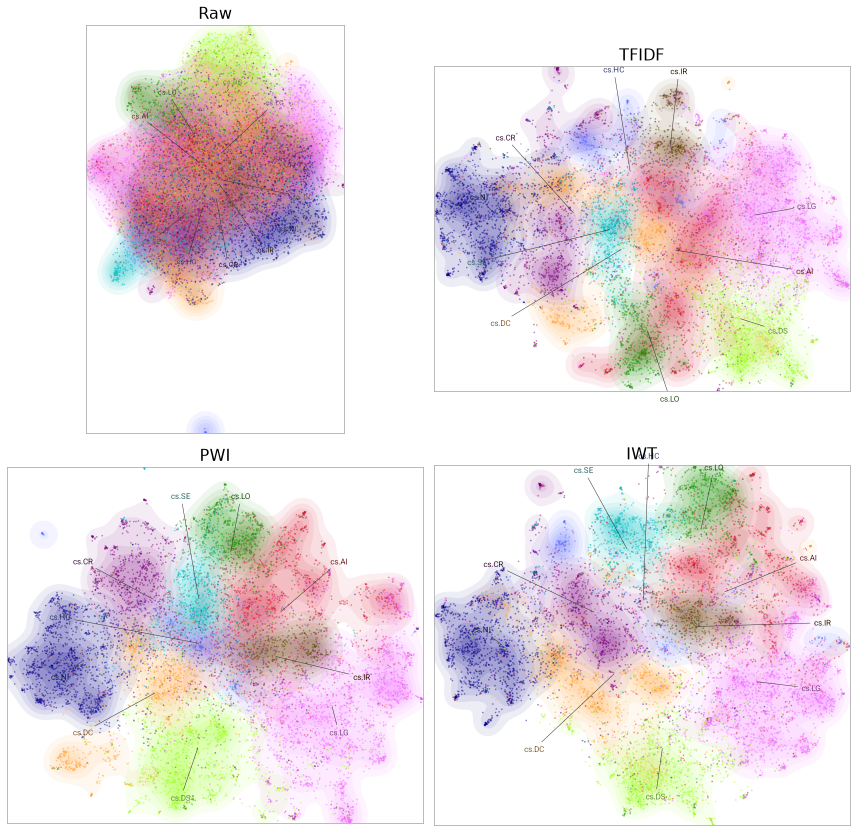

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
labels = df["category"].unique()
colors = glasbey.create_palette(palette_size=len(labels))
pal = dict(zip(labels, colors))

count_umapper = umap.UMAP(metric="cosine", random_state=42)
count_datamap = count_umapper.fit_transform(joint_counts)
datamapplot.create_plot(
    count_datamap, df["category"].values, label_color_map=pal, ax=axs[0, 0]
)
axs[0, 0].set_title("Raw", fontsize=16)
axs[0, 0].set_aspect("equal")
xlims, ylims = get_ax_lims(count_datamap)
axs[0, 0].set_xlim(xlims)
axs[0, 0].set_ylim(ylims)

tfidf_umapper = umap.UMAP(metric="cosine", random_state=42)
tfidf_datamap = tfidf_umapper.fit_transform(tfidf_joint_counts)
datamapplot.create_plot(
    tfidf_datamap, df["category"].values, label_color_map=pal, ax=axs[0, 1]
)
axs[0, 1].set_title("TFIDF", fontsize=16)
axs[0, 1].set_aspect("equal")
xlims, ylims = get_ax_lims(tfidf_datamap)
axs[0, 1].set_xlim(xlims)
axs[0, 1].set_ylim(ylims)

pwi_umapper = umap.UMAP(metric="cosine", random_state=42)
pwi_datamap = pwi_umapper.fit_transform(pwi_joint_counts)
datamapplot.create_plot(
    pwi_datamap, df["category"].values, label_color_map=pal, ax=axs[1, 0]
)
axs[1, 0].set_title("PWI", fontsize=16)
axs[1, 0].set_aspect("equal")
xlims, ylims = get_ax_lims(pwi_datamap)
axs[1, 0].set_xlim(xlims)
axs[1, 0].set_ylim(ylims)

iwt_umapper = umap.UMAP(metric="cosine", random_state=42)
iwt_datamap = iwt_umapper.fit_transform(iwt_joint_counts)
datamapplot.create_plot(
    iwt_datamap, df["category"].values, label_color_map=pal, ax=axs[1, 1]
)
axs[1, 1].set_title("IWT", fontsize=16)
axs[1, 1].set_aspect("equal")
xlims, ylims = get_ax_lims(iwt_datamap)
axs[1, 1].set_xlim(xlims)
axs[1, 1].set_ylim(ylims)

fig.tight_layout()

## Quantitative Measurements

It's clear to see that the transforms help separate the categories, but the quality of each looks pretty similar.
For a more quantitative approach, we can consider two measures:

- KNN Purity: the average proportion of k-nearest-neighbours (k = 15 in UMAP) in the high dimensional space that have the same class as the query point.
- Silhouette Score: a measure of how compact and well separated the classes are in UMAP's 2d output.

In [41]:
def knn_purity(knns, targets):
    knn_targets = targets[knns]
    same_target = np.sum(targets == knn_targets.T, axis=0)
    return np.mean(same_target / knns.shape[1])

In [16]:
umappers = [count_umapper, tfidf_umapper, pwi_umapper, iwt_umapper]
low_maps = [count_datamap, tfidf_datamap, pwi_datamap, iwt_datamap]
names = ["Raw", "TFIDF", "PWI", "IWT"]

print("Name | KNN Purity | Silhouette")
for name, datamap, umapper in zip(names, low_maps, umappers):
    print(
        f"{name:5}| {knn_purity(umapper._knn_indices, df['category'].values):10.3f} | {silhouette_score(datamap, df['category']):10.3f}"
    )

Name | KNN Purity | Silhouette
Raw  |      0.384 |     -0.110
TFIDF|      0.625 |      0.043
PWI  |      0.604 |      0.058
IWT  |      0.629 |      0.072


A slight win for the `InformationWeightTransformer`!

## Reweighting column groups

Recall that we constructed the final vectors by concatenating embeddings of several different variables (i.e. title, abstract, and references).
Similar to how we reweight the columns within an embedding to emphasize those with more information, we can reweight each embedding to emphasize those with more information.
To do this, we need to pass the concatenated counts to `InformationWeightTransformer` and use the `column_groups` parameter to tell it which columns belong to which variable. The `reweight_groups` parameter is set to `True` by default, but we set it explicitly to make it clear.

In [32]:
%%time
iwt = InformationWeightTransformer(reweight_groups=True)
column_groups = np.array(
    [0] * title_counts.shape[1] + [1] * word_counts.shape[1] + [2] * ref_counts.shape[1]
)
iwt_reweighted_joint_counts = iwt.fit_transform(
    joint_counts, column_groups=column_groups
)
iwt_reweighted_joint_counts

CPU times: user 1.52 s, sys: 46.8 ms, total: 1.57 s
Wall time: 1.59 s


<COOrdinate sparse matrix of dtype 'float64'
	with 1072500 stored elements and shape (9817, 29710)>

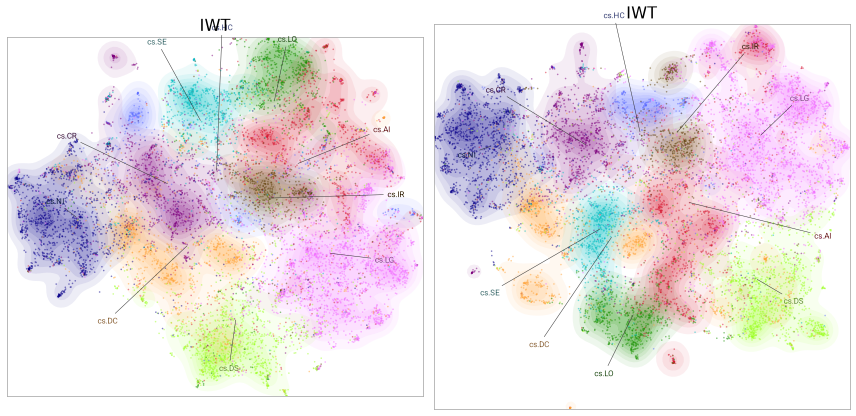

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
labels = df["category"].unique()
colors = glasbey.create_palette(palette_size=len(labels))
pal = dict(zip(labels, colors))

iwt_umapper = umap.UMAP(metric="cosine", random_state=42)
iwt_datamap = iwt_umapper.fit_transform(iwt_joint_counts)
datamapplot.create_plot(
    iwt_datamap, df["category"].values, label_color_map=pal, ax=axs[0]
)
axs[0].set_title("IWT", fontsize=16)
axs[0].set_aspect("equal")
xlims, ylims = get_ax_lims(iwt_datamap)
axs[0].set_xlim(xlims)
axs[0].set_ylim(ylims)

riwt_umapper = umap.UMAP(metric="cosine", random_state=42)
riwt_datamap = riwt_umapper.fit_transform(iwt_reweighted_joint_counts)
datamapplot.create_plot(
    riwt_datamap, df["category"].values, label_color_map=pal, ax=axs[1]
)
axs[1].set_title("IWT", fontsize=16)
axs[1].set_aspect("equal")
xlims, ylims = get_ax_lims(riwt_datamap)
axs[1].set_xlim(xlims)
axs[1].set_ylim(ylims)

fig.tight_layout()

In [19]:
umappers = [iwt_umapper, riwt_umapper]
low_maps = [iwt_datamap, riwt_datamap]
names = ["IWT", "RIWT"]

print("Name | KNN Purity | Silhouette")
for name, datamap, umapper in zip(names, low_maps, umappers):
    print(
        f"{name:5}| {knn_purity(umapper._knn_indices, df['category'].values):10.3f} | {silhouette_score(datamap, df['category']):10.3f}"
    )

Name | KNN Purity | Silhouette
IWT  |      0.629 |      0.072
RIWT |      0.670 |      0.087


Looks like the reweighting helps a bit too.

## Semi-supervised

The `InformationWeightTransformer` is also able to take advantage of any labels we may happen to have.
We can upweight features that differentiate these labels by computing the information weight on the count matrix mod labels.
That is, instead of one row per document we have one row per label, that is the sum of all rows with that label.
This is similar to a class based tfidf, but there are a few extra details to make the extension work.

Let's assume 5% of the data is labelled.

In [47]:
# Convert labels into an array of integers
cats = np.asarray(df["category"].unique())
cat_ids = {cat: i for i, cat in enumerate(cats)}
ss_labels = np.array([cat_ids[cat] for cat in df["category"].tolist()])

# Set most of the to noise (-1)
noise_prop = 0.95
rng = np.random.default_rng(seed=42)
noise_ids = rng.choice(
    len(ss_labels), size=int(len(ss_labels) * noise_prop), replace=False
)
ss_labels[noise_ids] = -1

In [48]:
%%time
# Pass the column groups to ensure we only compare to the within-group marginal
# But don't reweight the groups
iwt = InformationWeightTransformer(reweight_groups=False)
ss_iwt_joint_counts = iwt.fit_transform(
    joint_counts, ss_labels, column_groups=column_groups
)

riwt = InformationWeightTransformer(reweight_groups=True)
ss_riwt_joint_counts = riwt.fit_transform(
    joint_counts, ss_labels, column_groups=column_groups
)

CPU times: user 101 ms, sys: 25.4 ms, total: 127 ms
Wall time: 68.8 ms


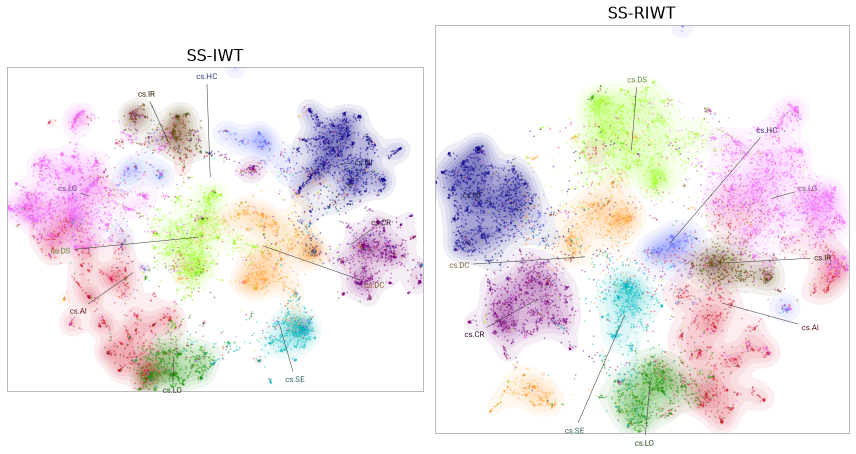

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
labels = df["category"].unique()
colors = glasbey.create_palette(palette_size=len(labels))
pal = dict(zip(labels, colors))

ss_iwt_umapper = umap.UMAP(metric="cosine", random_state=42)
ss_iwt_datamap = ss_iwt_umapper.fit_transform(ss_iwt_joint_counts)
datamapplot.create_plot(
    ss_iwt_datamap, df["category"].values, label_color_map=pal, ax=axs[0]
)
axs[0].set_title("SS-IWT", fontsize=16)
axs[0].set_aspect("equal")
xlims, ylims = get_ax_lims(ss_iwt_datamap)
axs[0].set_xlim(xlims)
axs[0].set_ylim(ylims)

ss_riwt_umapper = umap.UMAP(metric="cosine", random_state=42)
ss_riwt_datamap = ss_riwt_umapper.fit_transform(ss_riwt_joint_counts)
datamapplot.create_plot(
    ss_riwt_datamap, df["category"].values, label_color_map=pal, ax=axs[1]
)
axs[1].set_title("SS-RIWT", fontsize=16)
axs[1].set_aspect("equal")
xlims, ylims = get_ax_lims(ss_riwt_datamap)
axs[1].set_xlim(xlims)
axs[1].set_ylim(ylims)

fig.tight_layout()

In [49]:
umappers = [ss_iwt_umapper, ss_riwt_umapper]
low_maps = [ss_iwt_datamap, ss_riwt_datamap]
names = ["SS-IWT", "SS-RIWT"]

print("Name | KNN Purity | Silhouette")
for name, datamap, umapper in zip(names, low_maps, umappers):
    print(
        f"{name:5}| {knn_purity(umapper._knn_indices, df['category'].values):10.3f} | {silhouette_score(datamap, df['category']):10.3f}"
    )

Name | KNN Purity | Silhouette
SS-IWT|      0.695 |      0.159
SS-RIWT|      0.713 |      0.153


That looks a lot better.
It's not that surprising, since we did use a extra information that is not always readily available.

## Acknowledgements and References

Thank you to arXiv for use of its open access interoperability. This package was not reviewed or approved by, nor does it necessarily express or reflect the policies or opinions of, arXiv.

[1] Jason Priem, Heather Piwowar, and Richard Orr. OpenAlex: A fully-open index of scholarly works, authors, venues, institutions, and concepts. arXiv preprint (2022). doi: [10.48550/arXiv.2205.01833](https://doi.org/10.48550/arXiv.2205.01833)

[1] Akiko Aizawa. An information-theoretic perspective of tf-idf measures. Information Processing & Management, 39(1):45–65, 2003. doi: [10.1016/S0306-4573(02)00021-3](https://doi.org/10.1016/S0306-4573(02)00021-3)

[2]John Healy & Leland McInnes. Uniform manifold approximation and projection. Nature Reviews Methods Primers 4, 82 (2024). doi: [10.1038/s43586-024-00363-x](https://doi.org/10.1038/s43586-024-00363-x)